# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age
* fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [10]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')
# 6 to 7 figures

In [11]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


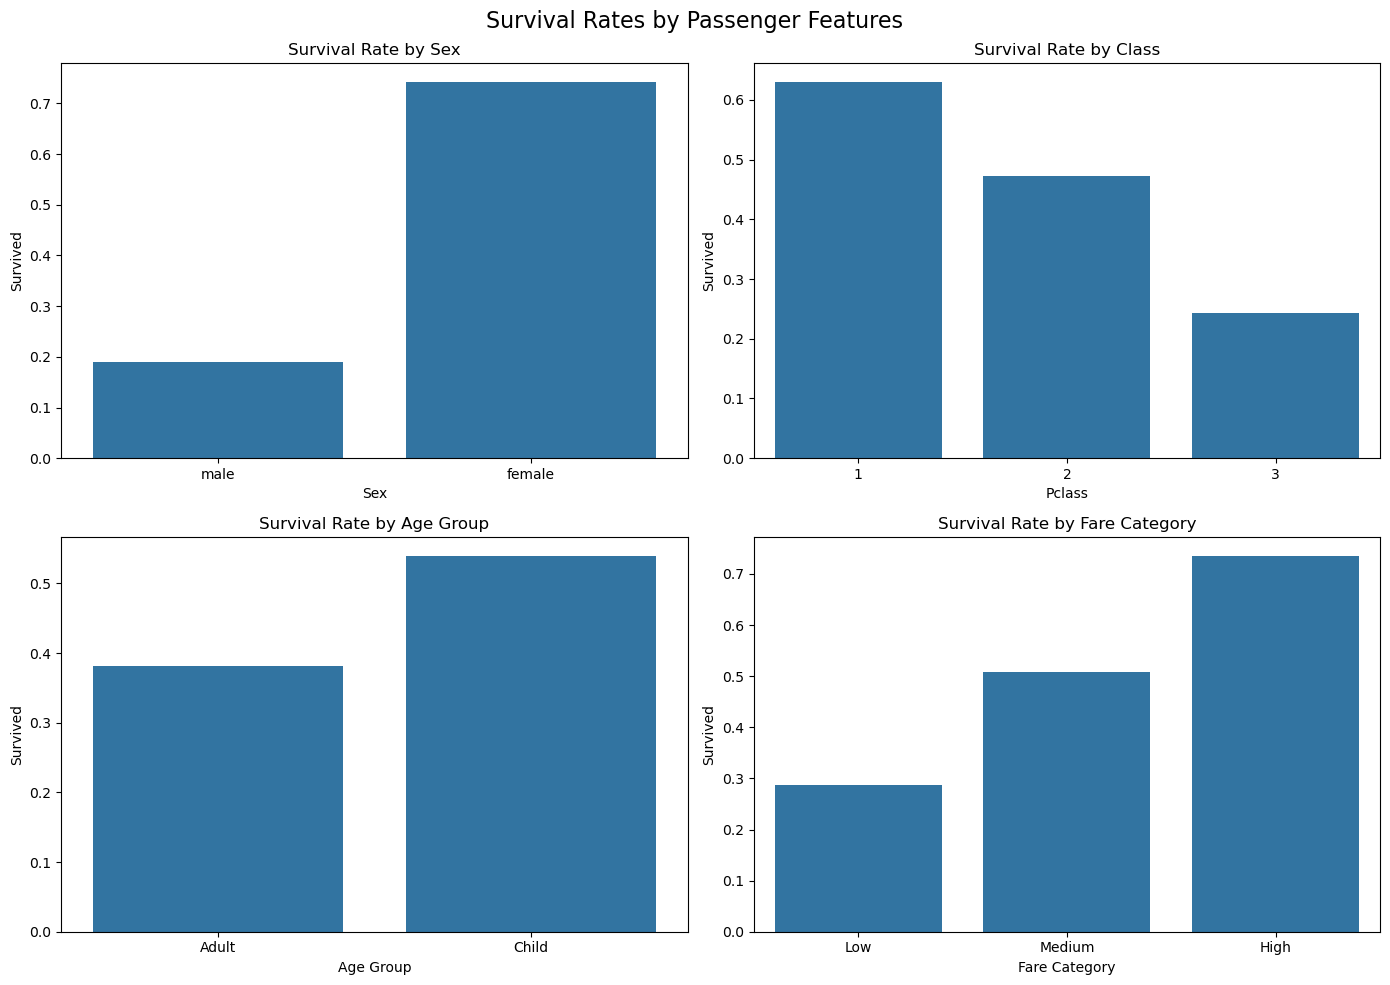

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data (if not already loaded)
df = pd.read_csv('titanic_passengers.csv')

# --- 1. Data Wrangling & Categorization ---
# Use .loc to create categorical buckets for Age and Fare
df.loc[df['Age'] < 18, 'Age Group'] = 'Child'
df.loc[df['Age'] >= 18, 'Age Group'] = 'Adult'

df.loc[df['Fare'] < 25, 'Fare Category'] = 'Low'
df.loc[(df['Fare'] >= 25) & (df['Fare'] < 100), 'Fare Category'] = 'Medium'
df.loc[df['Fare'] >= 100, 'Fare Category'] = 'High'

# --- 2. Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Survival Rates by Passenger Features', fontsize=16)

# Plot 1: Sex
sns.barplot(data=df, x='Sex', y='Survived', ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title('Survival Rate by Sex')

# Plot 2: Passenger Class
sns.barplot(data=df, x='Pclass', y='Survived', ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title('Survival Rate by Class')

# Plot 3: Age Group
sns.barplot(data=df, x='Age Group', y='Survived', ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title('Survival Rate by Age Group')

# Plot 4: Fare Category
sns.barplot(data=df, x='Fare Category', y='Survived', ax=axes[1, 1], order=['Low', 'Medium', 'High'], errorbar=None)
axes[1, 1].set_title('Survival Rate by Fare Category')

plt.tight_layout()
plt.show()

In [14]:
# --- Filter for "Most Likely to Survive" Candidates ---
# Profile: Female, 1st Class, High Fare, Survived
most_likely = df.loc[
    (df['Sex'] == 'female') & 
    (df['Pclass'] == 1) & 
    (df['Fare'] > 100) & 
    (df['Survived'] == 1)
]

print("--- Candidates for 'Most Likely to Survive' ---")
print(most_likely[['Name', 'Age', 'Fare']].head())

# --- Filter for "Least Likely to Survive" Candidates ---
# Profile: Male, 3rd Class, Low Fare, Did Not Survive
least_likely = df.loc[
    (df['Sex'] == 'male') & 
    (df['Pclass'] == 3) & 
    (df['Fare'] < 15) & 
    (df['Survived'] == 0)
]

print("\n--- Candidates for 'Least Likely to Survive' ---")
print(least_likely[['Name', 'Age', 'Fare']].head())

--- Candidates for 'Most Likely to Survive' ---
                                               Name   Age      Fare
31   Spencer, Mrs. William Augustus (Marie Eugenie)   NaN  146.5208
88                       Fortune, Miss. Mabel Helen  23.0  263.0000
195                            Lurette, Miss. Elise  58.0  146.5208
215                         Newell, Miss. Madeleine  31.0  113.2750
258                                Ward, Miss. Anna  35.0  512.3292

--- Candidates for 'Least Likely to Survive' ---
                              Name   Age    Fare
0          Braund, Mr. Owen Harris  22.0  7.2500
4         Allen, Mr. William Henry  35.0  8.0500
5                 Moran, Mr. James   NaN  8.4583
12  Saundercock, Mr. William Henry  20.0  8.0500
26         Emir, Mr. Farred Chehab   NaN  7.2250


In [15]:
# https://www.encyclopedia-titanica.org/titanic-survivor/mabel-helen-fortune.html
#most likely to survive
#Miss Mabel Helen Fortune
#She was 23 years old and a first class passenger. She loved a jazz band player named Harrison Driscoll. Because she survived she was able to marry him and have a child.
# she then got a deivorce and started to live with Charlotte Armstrong and sent her son to boarding school.

In [16]:
#https://www.encyclopedia-titanica.org/titanic-victim/william-henry-saundercock.html
#most likely to not survive
# Mr William Henry Saundercock
#Also known as "willie". Willie was 20 years old and a third class passenger. He grew up with 5 other siblings in Cornwall, England.
# He worked as a farm laborer and was traveling to America to start a new life.